In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv(r'C:\Users\Hp\Data Science Project\Project\Student_Risk\data\student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.shape

(395, 33)

In [5]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
# Create binary target variable
# G3 < 10 # At-risk (fail)
# G3 >= 10 # Not at-risk (pass)
df['at_risk'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,at_risk
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,4,4,5,4,11,9,9,9,1
391,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,3,14,16,16,0
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,3,3,3,3,3,10,8,7,1
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,0,11,12,10,0


In [10]:
df[['G3', 'at_risk']].head(10)

,G3,at_risk
0,6,1
1,6,1
2,10,0
3,15,0
4,10,0
5,15,0
6,11,0
7,6,1
8,19,0
9,15,0


In [11]:
print(df['at_risk'].value_counts())
print(df['at_risk'].value_counts(normalize=True))

at_risk
0    265
1    130
Name: count, dtype: int64
at_risk
0    0.670886
1    0.329114
Name: proportion, dtype: float64


In [ ]:
# Drop Unnecessary Columns
columns_to_drop = ['G3',
    'school', 'guardian', 'traveltime',
    'romantic', 'goout', 'Dalc', 'Walc', 'freetime',
    'health', 'famrel', 'nursery', 'reason', 'paid',
    'Mjob', 'Fjob', 'famsize', 'Pstatus', 'activities', 'higher']
df_filtered = df.drop(columns=columns_to_drop)
df_filtered

,sex,age,address,Medu,Fedu,studytime,failures,schoolsup,famsup,internet,absences,G1,G2,at_risk
0,F,18,U,4,4,2,0,yes,no,no,6,5,6,1
1,F,17,U,1,1,2,0,no,yes,yes,4,5,5,1
2,F,15,U,1,1,2,3,yes,no,yes,10,7,8,0
3,F,15,U,4,2,3,0,no,yes,yes,2,15,14,0
4,F,16,U,3,3,2,0,no,yes,no,4,6,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,U,2,2,2,2,no,yes,no,11,9,9,1
391,M,17,U,3,1,1,0,no,no,yes,3,14,16,0
392,M,21,R,1,1,1,3,no,no,no,3,10,8,1
393,M,18,R,3,2,1,0,no,no,yes,0,11,12,0


In [ ]:
# Define Features and Target
x = df_filtered.drop(columns= 'at_risk')
y = df_filtered['at_risk'] # define the predicted variable

In [14]:
print(x.shape)
print(y.shape)

(395, 13)
(395,)


In [15]:
# Identify Categorical Columns
x.dtypes

sex          object
age           int64
address      object
Medu          int64
Fedu          int64
studytime     int64
failures      int64
schoolsup    object
famsup       object
internet     object
absences      int64
G1            int64
G2            int64
dtype: object

In [16]:
categorical_cols = x.select_dtypes(include=['object']).columns
categorical_cols

Index(['sex', 'address', 'schoolsup', 'famsup', 'internet'], dtype='object')

In [17]:
# Encode categorical variables
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
print(x.shape)
print(x.head(10))

(395, 13)
   age  Medu  Fedu  studytime  failures  absences  G1  G2  sex_M  address_U  \
0   18     4     4          2         0         6   5   6  False       True   
1   17     1     1          2         0         4   5   5  False       True   
2   15     1     1          2         3        10   7   8  False       True   
3   15     4     2          3         0         2  15  14  False       True   
4   16     3     3          2         0         4   6  10  False       True   
5   16     4     3          2         0        10  15  15   True       True   
6   16     2     2          2         0         0  12  12   True       True   
7   17     4     4          2         0         6   6   5  False       True   
8   15     3     2          2         0         0  16  18   True       True   
9   15     3     4          2         0         0  14  15   True       True   

   schoolsup_yes  famsup_yes  internet_yes  
0           True       False         False  
1          False        True  

In [ ]:
# Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2, # 80% training, 20% testing
    random_state = 42,
    stratify = y # preserves at-risk distribution
)

In [ ]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators = 100,  # Number of trees
    max_depth = 10,  # Maximum depth of each tree
    min_samples_split = 5,  # Minimum samples to split a node
    min_samples_leaf = 2,  # Minimum samples in a leaf
    class_weight = 'balanced',  # Handle class imbalance
    random_state = 42,  # For reproducibility
    n_jobs = -1  # Use all CPU cores
)

# Training the model
rf_model.fit(x_train, y_train)
print('Model training complete')

Model training complete


In [20]:
# Make Predictions
y_pred = rf_model.predict(x_test)
y_pred_proba = rf_model.predict_proba(x_test)[:, 1] # Probability of being at-risk

# Show some example predictions
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Risk_Probability': y_pred_proba
})

print("\n Sample Predictions (first 10):")
print(results_df.head(10))

# Count correct predictions
correct = (y_pred == y_test).sum()
total = len(y_test)
print(f"\n Correct predictions: {correct}/{total} ({correct/total*100:.1f}%)")


 Sample Predictions (first 10):
   Actual  Predicted  Risk_Probability
0       1          1          0.965853
1       0          0          0.262424
2       0          1          0.787541
3       1          1          0.890894
4       1          1          0.801257
5       0          0          0.057742
6       0          0          0.147566
7       0          0          0.012469
8       1          1          0.822879
9       0          0          0.041508

 Correct predictions: 72/79 (91.1%)


In [21]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Performance Metrics:")
print(f"  Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"  Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"  Recall:    {recall:.3f} ({recall*100:.1f}%)")
print(f"  F1-Score:  {f1:.3f} ({f1*100:.1f}%)")


Performance Metrics:
  Accuracy:  0.911 (91.1%)
  Precision: 0.852 (85.2%)
  Recall:    0.885 (88.5%)
  F1-Score:  0.868 (86.8%)


In [22]:
print("Metric Interpretations:")
print(f"  • Accuracy: {accuracy*100:.1f}% of all predictions were correct")
print(f"  • Precision: {precision*100:.1f}% of students flagged as at-risk actually were")
print(f"  • Recall: {recall*100:.1f}% of actual at-risk students were identified")
print(f"  • F1-Score: Harmonic mean of precision and recall")

Metric Interpretations:
  • Accuracy: 91.1% of all predictions were correct
  • Precision: 85.2% of students flagged as at-risk actually were
  • Recall: 88.5% of actual at-risk students were identified
  • F1-Score: Harmonic mean of precision and recall


In [23]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'At-Risk (1)']))

              precision    recall  f1-score   support

    Safe (0)       0.94      0.92      0.93        53
 At-Risk (1)       0.85      0.88      0.87        26

    accuracy                           0.91        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.91      0.91      0.91        79



In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"  True Negatives (correctly predicted Safe): {cm[0,0]}")
print(f"  False Positives (Safe predicted as At-Risk): {cm[0,1]}")
print(f"  False Negatives (At-Risk predicted as Safe): {cm[1,0]} CRITICAL!")
print(f"  True Positives (correctly predicted At-Risk): {cm[1,1]}")

[[49  4]
 [ 3 23]]
  True Negatives (correctly predicted Safe): 49
  False Positives (Safe predicted as At-Risk): 4
  False Negatives (At-Risk predicted as Safe): 3 CRITICAL!
  True Positives (correctly predicted At-Risk): 23


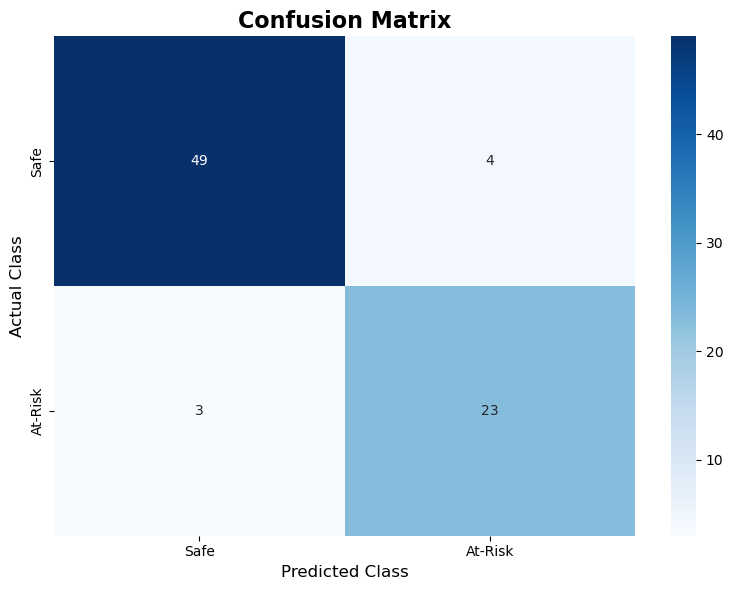

In [25]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Safe', 'At-Risk'],
            yticklabels=['Safe', 'At-Risk'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

          feature  importance
7              G2    0.481705
6              G1    0.302979
5        absences    0.040787
4        failures    0.037653
0             age    0.030052
2            Fedu    0.021749
1            Medu    0.018012
10  schoolsup_yes    0.014145
3       studytime    0.012050
12   internet_yes    0.011336
9       address_U    0.010933
8           sex_M    0.010708
11     famsup_yes    0.007891


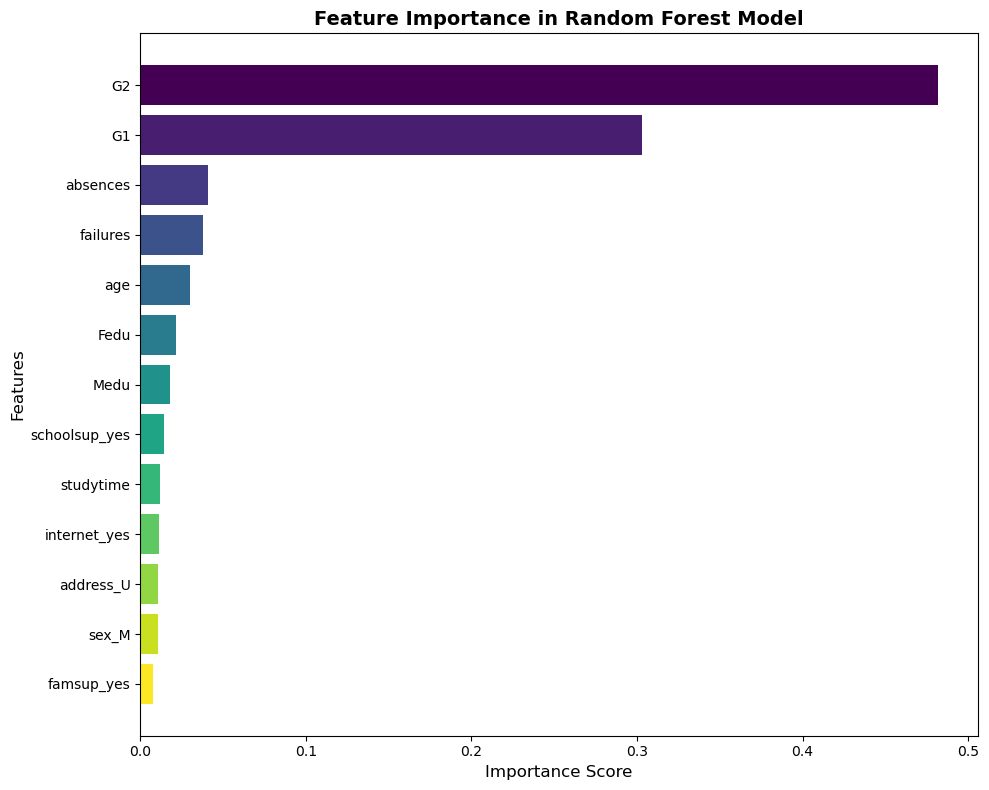

In [28]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in Random Forest Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()


In [29]:
# Cross-Validation
from sklearn.model_selection import cross_val_score, cross_validate
# Test with 5 different train/test splits
cv_scores = cross_val_score(
    rf_model,      # The trained model
    x, y,          # All the data
    cv=5,          # 5 different splits
    scoring='recall'  # Use recall (most important)
)

print("\n Recall Score for Each Fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f} ({score*100:.1f}%)")

print(f"\n Cross-Validation Results:")
print(f"  Mean Recall:   {cv_scores.mean():.3f} ({cv_scores.mean()*100:.1f}%)")
print(f"  Std Deviation: {cv_scores.std():.3f}")
print(f"  Range: {cv_scores.min():.3f} to {cv_scores.max():.3f}")

# Interpretation
if cv_scores.std() < 0.05:
    print("\n EXCELLENT - Model is stable and consistent!")
elif cv_scores.std() < 0.10:
    print("\n GOOD - Model shows acceptable consistency")
else:
    print("\n  Model performance varies - consider more data")


 Recall Score for Each Fold:
  Fold 1: 0.808 (80.8%)
  Fold 2: 0.962 (96.2%)
  Fold 3: 0.962 (96.2%)
  Fold 4: 0.923 (92.3%)
  Fold 5: 0.923 (92.3%)

 Cross-Validation Results:
  Mean Recall:   0.915 (91.5%)
  Std Deviation: 0.057
  Range: 0.808 to 0.962

 GOOD - Model shows acceptable consistency


In [30]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(
    rf_model, x, y, 
    cv=5, 
    scoring=scoring,
    return_train_score=True  # Check for overfitting
)

print("\n Average Performance Across 5 Folds:")
print(f"\n{'Metric':<12} {'Training':<12} {'Testing':<12} {'Gap':<10}")
print("-" * 50)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    train_mean = cv_results[f'train_{metric}'].mean()
    test_mean = cv_results[f'test_{metric}'].mean()
    gap = train_mean - test_mean
    
    print(f"{metric:<12} {train_mean:<12.3f} {test_mean:<12.3f} {gap:<10.3f}")


 Average Performance Across 5 Folds:

Metric       Training     Testing      Gap       
--------------------------------------------------
accuracy     0.970        0.909        0.061     
precision    0.923        0.829        0.094     
recall       0.992        0.915        0.077     
f1           0.956        0.868        0.088     


In [31]:
import joblib

# Save the model
joblib.dump(rf_model, 'at_risk_model.joblib')

# Save the list of feature names so the prototype knows the exact order of inputs.
joblib.dump(x.columns.tolist(), 'model_features.joblib')

print(" Model and features saved successfully!")

 Model and features saved successfully!
